## Plan

This jupyter notebook breaks down the flow of using OCHRE for building 
predictive control

Functions for the rest of the script:

In [1]:
from datetime import datetime

import cvxpy as cp
import numpy as np

In [2]:
def attach_epw_to_df(df, epw_path,
                     keep_cols=("Dry Bulb (C)",
                                "Relative Humidity (%)",
                                "Global Horizontal Radiation (Wh/m^2)",
                                "Wind Speed (m/s)"),
                     out_names=("Temperature - Outdoor (C) [EPW]",
                                "Relative Humidity - Outdoor (%) [EPW]",
                                "Global Horizontal Irradiance (W/m^2) [EPW]",  # EPW is Wh/m² (hourly avg)
                                "Wind Speed - Outdoor (m/s) [EPW]")):
    # --- read EPW ---
    cols = [
        "Year","Month","Day","Hour","Minute","Flags",
        "Dry Bulb (C)","Dew Point (C)","Relative Humidity (%)","Atmos Pressure (Pa)",
        "Extraterrestrial Horizontal Radiation (Wh/m^2)",
        "Extraterrestrial Direct Normal Radiation (Wh/m^2)",
        "Horizontal IR Intensity (Wh/m^2)",
        "Global Horizontal Radiation (Wh/m^2)",
        "Direct Normal Radiation (Wh/m^2)",
        "Diffuse Horizontal Radiation (Wh/m^2)",
        "Global Horizontal Illuminance (lux)",
        "Direct Normal Illuminance (lux)",
        "Diffuse Horizontal Illuminance (lux)",
        "Zenith Luminance (Cd/m^2)",
        "Wind Direction (deg)","Wind Speed (m/s)","Total Sky Cover (tenths)",
        "Opaque Sky Cover (tenths)","Visibility (km)","Ceiling Height (m)",
        "Present Weather Observation","Present Weather Codes",
        "Precipitable Water (mm)","Aerosol Optical Depth (thousandths)",
        "Snow Depth (cm)","Days Since Last Snowfall",
        "Albedo","Liquid Precipitation Depth (mm)","Liquid Precipitation Quantity (hr)"
    ]
    epw = pd.read_csv(epw_path, skiprows=8, header=None, names=cols)

    # --- Build timestamp ignoring EPW 'Year' ---
    # EPW Hour = 1..24 marks END of hour → convert to start of hour
    h = epw["Hour"].to_numpy()
    carry = (h == 24).astype(int)
    hour0 = (h % 24)

    # choose a single year: the sim's year
    sim_year = int(df.index[0].year)

    dt = pd.to_datetime({
        "year": sim_year,                            # force a single year
        "month": epw["Month"],
        "day": epw["Day"],
        "hour": hour0,
        # EPW minute is usually 0 for hourly TMY; include if present
        "minute": epw["Minute"] if "Minute" in epw else 0
    })
    # shift hour=24 rows to next day (now within the same sim_year)
    dt = dt + pd.to_timedelta(carry, unit="D")

    wx = epw.set_index(dt)[list(keep_cols)].copy()
    wx.columns = list(out_names)

    # RH sanity
    if "Relative Humidity - Outdoor (%) [EPW]" in wx:
        wx["Relative Humidity - Outdoor (%) [EPW]"] = wx["Relative Humidity - Outdoor (%) [EPW]"].clip(0, 100)

    # Align to sim timeline; hourly → sub-hourly via forward-fill
    # If df has irregular start (e.g., not exactly at :00), also bfill edges.
    wx_aligned = wx.reindex(df.index, method="ffill").bfill()

    # Join
    out = df.join(wx_aligned, how="left")
    return out




In [3]:
def weather_predict(epw_path, t_now, n_horizon):
    cols = [
        "Year","Month","Day","Hour","Minute","Flags",
        "Dry Bulb (C)","Dew Point (C)","Relative Humidity (%)","Atmos Pressure (Pa)",
        "Extraterrestrial Horizontal Radiation (Wh/m^2)",
        "Extraterrestrial Direct Normal Radiation (Wh/m^2)",
        "Horizontal IR Intensity (Wh/m^2)",
        "Global Horizontal Radiation (Wh/m^2)",
        "Direct Normal Radiation (Wh/m^2)",
        "Diffuse Horizontal Radiation (Wh/m^2)",
        "Global Horizontal Illuminance (lux)",
        "Direct Normal Illuminance (lux)",
        "Diffuse Horizontal Illuminance (lux)",
        "Zenith Luminance (Cd/m^2)",
        "Wind Direction (deg)","Wind Speed (m/s)","Total Sky Cover (tenths)",
        "Opaque Sky Cover (tenths)","Visibility (km)","Ceiling Height (m)",
        "Present Weather Observation","Present Weather Codes",
        "Precipitable Water (mm)","Aerosol Optical Depth (thousandths)",
        "Snow Depth (cm)","Days Since Last Snowfall",
        "Albedo","Liquid Precipitation Depth (mm)","Liquid Precipitation Quantity (hr)"
    ]
    epw = pd.read_csv(epw_path, skiprows=8, header=None, names=cols)

    # Build a datetime index for the EPW (assumes typical EPW hour stamps 1..24)
    # EPW "Hour" is 1..24 -> convert to 0..23
    epw["Hour0"] = epw["Hour"] - 1
    # Use a dummy year (EPW year field is unreliable). Align by Month/Day/Hour only.
    dt_index = pd.to_datetime(dict(
        year=2001, month=epw["Month"], day=epw["Day"], hour=epw["Hour0"], minute=0
    ))
    epw.index = dt_index

    # Build the forecast index (hourly)
    idx = pd.date_range(t_now.floor('h'), periods=n_horizon, freq='h')  # 
    # include current hour
    # Map by (month, day, hour); for a real forecast you’d use an API—this is EPW “typical”.
    epw_key = list(zip(epw.index.month, epw.index.day, epw.index.hour))
    map_df = epw[["Dry Bulb (C)","Relative Humidity (%)","Wind Speed (m/s)"]].copy()
    map_df["m"] = epw.index.month; map_df["d"] = epw.index.day; map_df["h"] = epw.index.hour

    out = []
    for ts in idx:
        subset = map_df[(map_df["m"]==ts.month)&(map_df["d"]==ts.day)&(map_df["h"]==ts.hour)]
        if subset.empty:
            subset = map_df[(map_df["m"]==ts.month)&(map_df["h"]==ts.hour)]
        row = subset.iloc[0]
        out.append([row["Dry Bulb (C)"], row["Relative Humidity (%)"], row["Wind Speed (m/s)"]])

    df = pd.DataFrame(out, index=idx, columns=["Dry Bulb (C)","Relative Humidity (%)","Wind Speed (m/s)"])
    return df

In [4]:
def electricity_price(t_now, timestep, N, rate_type="flat"):
    """
    Build an electricity price vector for an MPC horizon.

    Parameters
    ----------
    t_now : datetime.datetime
        Current simulation time (start of the MPC horizon).
    timestep : float
        MPC time-step in minutes (e.g., 60 for 1 hour).
    N : int
        Prediction horizon length (number of MPC steps).
    rate_type : {"flat", "tou"}
        - "flat": constant 0.093 $/kWh
        - "tou":  0.21 $/kWh from 5–9 pm (17:00–21:00, 21:00 exclusive),
                 0.07 $/kWh otherwise.

    Returns
    -------
    c_elec : np.ndarray, shape (N,)
        Electricity price at each MPC step in $/kWh.
    """

    # Build the actual timestamps over the horizon
    times = [t_now + dt.timedelta(minutes=k * timestep) for k in range(N)]

    rate_type = rate_type.lower()

    if rate_type == "flat":
        # Constant flat rate
        return np.full(N, 0.093)

    elif rate_type == "tou":
        prices = []
        for t_i in times:
            hour = t_i.hour
            # Peak from 5–9 pm: interpret as 17:00–21:00 (21:00 exclusive)
            if 17 <= hour < 21:
                prices.append(0.21)
            else:
                prices.append(0.07)
        return np.array(prices)

    else:
        raise ValueError(f"Unknown rate_type '{rate_type}'. Use 'flat' or 'tou'.")

In [5]:
def comfort_schedule(start_time, n_horizon, time_step):
    """
    Returns time-varying T_min and T_max arrays for the next n_horizon hours.
    
    - 19–23 °C between 6 PM (18:00) and 9 AM (09:00)
    - 16–27 °C otherwise
    """
    
    freq_string = f'{time_step}min'
    
    # Hourly horizon
    hours = pd.date_range(start=start_time, periods=n_horizon, freq=freq_string)

    T_min = np.zeros(n_horizon)
    T_max = np.zeros(n_horizon)

    for i, h in enumerate(hours.hour):
        if h >= 18 or h < 9:     # 6 PM–9 AM
            T_min[i] = 19.0
            T_max[i] = 23.0
        else:                    # 9 AM–6 PM
            T_min[i] = 16.0
            T_max[i] = 27.0

    return T_min, T_max

## Step 1
Initialize the building and weather data. Note, how scheduling is also 
initialized, but this is for other power loads in the house (washer, dryer, 
etc.) 

In [6]:
import os
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from ochre import CreateFigures
from ochre import Dwelling
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
default_input_path = os.path.join(PROJECT_ROOT, "ochre", "defaults")

ModuleNotFoundError: No module named 'ochre'

In [8]:
timestep_sim = 1 # timestep of simulation in minutes
timestep_control = 60 # in minutes
min_off_time = 300 #seconds
min_on_time = min_off_time
HP_deadband = 2  # Celsius
ER_lowerbound = 3 # celsius

In [9]:

dwelling_args = {
    # Timing parameters
    "start_time": dt.datetime(2018, 1, 1, 0, 0),  # (year, month, day, hour, 
    # minute)
    "time_res": dt.timedelta(minutes=timestep_sim),         # time resolution
    # of the simulation
    "duration": dt.timedelta(days=0.5),             # duration of the 
    # simulation to just initialize. Will change later
    "verbosity": 6,

    # Input files
    "hpxml_file": os.path.join(default_input_path, "Input Files", 
                               "bldg0112631-up11.xml"),
    "hpxml_schedule_file": os.path.join(default_input_path, "Input Files", "bldg0112631_schedule.csv"),
    "weather_file": os.path.join(default_input_path, "Weather", "USA_CO_Denver.Intl.AP.725650_TMY3.epw"),
}

# Create Dwelling model
dwelling = Dwelling(**dwelling_args)
heater = dwelling.get_equipment_by_end_use("HVAC Heating")
schedule = heater.schedule
schedule["HVAC Heating Deadband (C)"] = HP_deadband

#peak_times = (schedule.index.hour >= 10) & (schedule.index.hour < 15)
#schedule.loc[peak_times, "HVAC Heating Setpoint (C)"] -= 3
heater.min_on_time = min_on_time#300#600*1.5          # minimum cycle on for 
# (seconds)
heater.min_off_time = min_off_time#300#600*1.5         # minimum cycle off for (seconds)
heater.er_setpoint_offset = ER_lowerbound
heater.reset_time()

df, metrics, hourly = dwelling.simulate()

2025-12-12 17:11:39.979296 - ochre at 2018-01-01 00:00:00: Initializing ochre (OCHRE v0.9.1)
2025-12-12 17:11:39.979758 - ochre at 2018-01-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre.csv
2025-12-12 17:11:39.987919 - ochre at 2018-01-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_metrics.csv
2025-12-12 17:11:39.988112 - ochre at 2018-01-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_hourly.csv
2025-12-12 17:11:39.988495 - ochre at 2018-01-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_schedule.csv
2025-12-12 17:11:42.058368 - ochre at 2018-01-01 00:00:00: Dwelling Initialized
2025-12-12 17:11:42.059196 - ochre at 2018-01-01 00:00:00: Running Simulation for 12:00:00
2025-12-12 17:11:42.

## Baseline control loop

In [10]:
training_days = 0
setpoint = 23
t_step_ctr = timestep_control
n_horizon = 24 # hours
T_pref = 21 # Celsius

In [11]:
plan_cache = None        # holds last computed hourly plan
plan_valid_until = None  # timestamp when the current plan expires
#t_step_ctr = 3600.0      # [s] controller timestep (1 hour)
n_horizon   = 24         # 24 hours

In [12]:
j = 0
sim_start = timestep_sim*60*24

In [23]:
sim_start

1440

In [13]:
# --- Set up dwelling and time grid ---
start_time = dt.datetime(2018, 2, 1 + training_days, 0, 0)

dwelling_args.update({
    "start_time": start_time,
    "duration": dt.timedelta(days=30),
    "initialization_time": dt.timedelta(days=1),
    "verbosity": 9
    }
)

dwelling = Dwelling(**dwelling_args)
hvac = dwelling.get_equipment_by_end_use("HVAC Heating")
hvac.er_setpoint_offset = ER_lowerbound
er = hvac.er_capacity_rated/1000

schedule = hvac.schedule
schedule["HVAC Heating Deadband (C)"] = HP_deadband

schedule["HVAC Heating Setpoint (C)"] = 21.0
peak_times = (schedule.index.hour >= 9) & (schedule.index.hour < 18)
schedule.loc[peak_times, "HVAC Heating Setpoint (C)"] = 21.0 - 3.0  # → 18°C

hvac.min_on_time = min_on_time
hvac.min_off_time = min_off_time
hvac.er_setpoint_offset = ER_lowerbound
hvac.reset_time()

df_ctr, metrics_ctr, hourly_ctr = dwelling.simulate()

2025-12-12 17:11:42.369566 - ochre at 2018-02-01 00:00:00: Initializing ochre (OCHRE v0.9.1)
2025-12-12 17:11:42.370172 - ochre at 2018-02-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre.csv
2025-12-12 17:11:42.373468 - ochre at 2018-02-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_metrics.csv
2025-12-12 17:11:42.373589 - ochre at 2018-02-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_hourly.csv
2025-12-12 17:11:44.894012 - ochre at 2018-02-01 00:00:00: Saved schedule to: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_schedule.csv
2025-12-12 17:11:45.234256 - ochre at 2018-02-01 00:00:00: Running initialization for 1 day, 0:00:00
2025-12-12 17:11:45.888465 - ochre at 2018-02-01 00:00:00: Dwelling Initialized
2025-12-12 17:11:45.908

In [26]:
days_eval = 7*24*60
pref_hours = list(range(18, 24)) + list(range(0, 9))  # 6pm–midnight and 0–9am

df_mpc = df_ctr[df_ctr["TimeIndex"] >= sim_start] if "TimeIndex" in df_ctr else df_ctr.iloc[sim_start:].copy()
df_mpc = df_mpc.iloc[:days_eval].copy()
# Ensure datetime index is present
df_mpc.index = pd.to_datetime(df_mpc.index)

# --- 2. Filter for preference hours (6 PM → 9 AM) ---
df_pref = df_mpc[df_mpc.index.hour.isin(pref_hours)]

# --- 3. Extract temperature error ---
T_in = df_pref["Temperature - Indoor (C)"].values
err = T_in - T_pref

# RMSE
rmse = np.sqrt(np.mean(err**2))

# --- 4. Compute energy usage (kWh) ---
# Assuming 1–minute resolution and HVAC heating power column:
power_col_candidates = ['HVAC Heating Electric Power (kW)']

if not power_col_candidates:
    raise KeyError("Could not find HVAC kW power column in df_ctr. Tell me your column name.")

P_kW = df_mpc[power_col_candidates[0]]

# 1 minute = 1/60 hour
dt_hours = 1.0/60.0
energy_kWh_ts = P_kW * dt_hours         # per-timestep energy [kWh]
energy_kWh = energy_kWh_ts.sum()        # total energy [kWh]

# --- 4b. Use electricity_price() to compute cost (flat + TOU) ---
t_now = df_mpc.index[0]                 # start of MPC horizon / eval period
timestep_min = 1.0                      # 1-minute simulation timestep
N = len(df_mpc)                         # number of timesteps

# Price vectors [$ / kWh] over the horizon
c_flat = electricity_price(t_now, timestep_min, N, rate_type="flat")
c_tou  = electricity_price(t_now, timestep_min, N, rate_type="tou")

# Make sure they are NumPy arrays
c_flat = np.asarray(c_flat, dtype=float)
c_tou  = np.asarray(c_tou, dtype=float)

# Cost = sum_t (energy_t [kWh] * price_t [$ / kWh])
cost_flat = np.dot(energy_kWh_ts, c_flat)
cost_tou  = np.dot(energy_kWh_ts, c_tou)


# --- 5. Print results ---
print("=== Base Performance ===")
print(f"Preference temperature: {T_pref:.2f} °C (21 °F)")
print(f"Temperature Pref RMSE during occupancy:       {rmse:.3f} °C")
print(f"Energy usage:           {energy_kWh:.2f} kWh")
print(f"Number of minutes:      {len(df_mpc)}")

print("\n=== Cost of Operation ===")
print(f"Flat rate (0.093 $/kWh):                ${cost_flat:.2f}")
print(f"TOU rate (0.21 peak 17–21 h, else 0.07): ${cost_tou:.2f}")

=== Base Performance ===
Preference temperature: 21.00 °C (21 °F)
Temperature Pref RMSE during occupancy:       1.411 °C
Energy usage:           356.17 kWh
Number of minutes:      10080

=== Cost of Operation ===
Flat rate (0.093 $/kWh):                $33.12
TOU rate (0.21 peak 17–21 h, else 0.07): $36.69


In [27]:
df_mpc.index

DatetimeIndex(['2018-02-02 00:00:00', '2018-02-02 00:01:00',
               '2018-02-02 00:02:00', '2018-02-02 00:03:00',
               '2018-02-02 00:04:00', '2018-02-02 00:05:00',
               '2018-02-02 00:06:00', '2018-02-02 00:07:00',
               '2018-02-02 00:08:00', '2018-02-02 00:09:00',
               ...
               '2018-02-08 23:50:00', '2018-02-08 23:51:00',
               '2018-02-08 23:52:00', '2018-02-08 23:53:00',
               '2018-02-08 23:54:00', '2018-02-08 23:55:00',
               '2018-02-08 23:56:00', '2018-02-08 23:57:00',
               '2018-02-08 23:58:00', '2018-02-08 23:59:00'],
              dtype='datetime64[ns]', name='Time', length=10080, freq=None)

<Axes: xlabel='Time'>

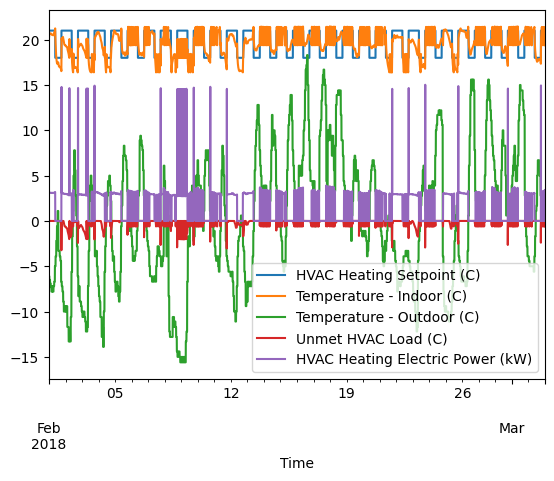

In [15]:
cols_to_plot = [
    "HVAC Heating Setpoint (C)",
    "Temperature - Indoor (C)",
    "Temperature - Outdoor (C)",
    "Unmet HVAC Load (C)",
    "HVAC Heating Electric Power (kW)",
]
df_ctr.loc[:, cols_to_plot].plot()

In [16]:
df_ctr

,Total Electric Power (kW),Total Reactive Power (kVAR),Total Gas Power (therms/hour),Total Electric Energy (kWh),Total Reactive Energy (kVARh),Total Gas Energy (therms),Water Heating Electric Power (kW),Other Electric Power (kW),HVAC Heating Electric Power (kW),HVAC Cooling Electric Power (kW),...,Garage Furniture Garage Film Coefficient (m^2-K/W),Attic Wall Attic LWR Gain (W),Attic Wall Attic Surface Temperature (C),Attic Wall Attic Film Coefficient (m^2-K/W),Attic Roof Attic LWR Gain (W),Attic Roof Attic Surface Temperature (C),Attic Roof Attic Film Coefficient (m^2-K/W),Attic Floor Attic LWR Gain (W),Attic Floor Attic Surface Temperature (C),Attic Floor Attic Film Coefficient (m^2-K/W)
Time,,,,,,,,,,,,,,,,,,,,,
2018-02-01 00:00:00,3.398673,2.190681,0.0,0.056645,0.036511,0.0,0.001,0.230603,3.100762,0.05,...,0.325486,-13.316635,-9.562181,0.325486,216.917414,-10.269587,0.536264,-203.600779,-9.256878,0.561134
2018-02-01 00:01:00,3.399522,2.191229,0.0,0.056659,0.036520,0.0,0.001,0.230603,3.101611,0.05,...,0.325486,-12.945621,-9.565427,0.325486,217.670875,-10.268701,0.536264,-204.725253,-9.251452,0.561134
2018-02-01 00:02:00,3.400337,2.191756,0.0,0.056672,0.036529,0.0,0.001,0.230603,3.102426,0.05,...,0.325486,-12.472556,-9.566018,0.325486,218.413749,-10.263494,0.536264,-205.941193,-9.241548,0.561134
2018-02-01 00:03:00,3.401123,2.192263,0.0,0.056685,0.036538,0.0,0.001,0.230603,3.103212,0.05,...,0.325486,-11.768211,-9.559020,0.325486,218.426615,-10.245288,0.536264,-206.658404,-9.221715,0.561134
2018-02-01 00:04:00,3.401883,2.192755,0.0,0.056698,0.036546,0.0,0.001,0.230603,3.103972,0.05,...,0.325486,-11.242028,-9.549625,0.325486,218.160737,-10.226857,0.536264,-206.918709,-9.203444,0.561134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-03-02 23:55:00,3.689698,2.379609,0.0,0.061495,0.039660,0.0,0.001,0.242170,3.379820,0.05,...,0.325486,1.528075,1.436552,0.325486,134.112634,1.186883,0.536264,-135.640710,1.761107,0.561134
2018-03-02 23:56:00,3.692310,2.381297,0.0,0.061539,0.039688,0.0,0.001,0.242170,3.382432,0.05,...,0.325486,1.714756,1.442881,0.325486,133.892587,1.196283,0.536264,-135.607343,1.769931,0.561134
2018-03-02 23:57:00,3.694875,2.382954,0.0,0.061581,0.039716,0.0,0.001,0.242170,3.384997,0.05,...,0.325486,1.890813,1.449757,0.325486,133.681613,1.206064,0.536264,-135.572426,1.779149,0.561134


In [17]:
heater = dwelling.get_equipment_by_end_use("HVAC Heating")
heater.temp_deadband
heater.deadband_offset
heater.er_setpoint_offset
heater.hp_lockout_temp
heater.er_lockout_temp
heater.er_hard_lockout_time
heater.er_soft_lockout_time


datetime.timedelta(0)

In [18]:
db   = heater.temp_deadband
off  = heater.deadband_offset
er_o = heater.er_setpoint_offset
hvac_mult = heater.hvac_mult  # +1 for heating

# HP on-threshold (from run_thermostat_control)
T_hp_on  = df["HVAC Heating Setpoint (C)"] - hvac_mult * db * (1 - off)

# ER on-threshold (from run_er_thermostat_control)
T_er_on  = df["HVAC Heating Setpoint (C)"] - er_o


In [19]:
heater.er_setpoint_offset

3

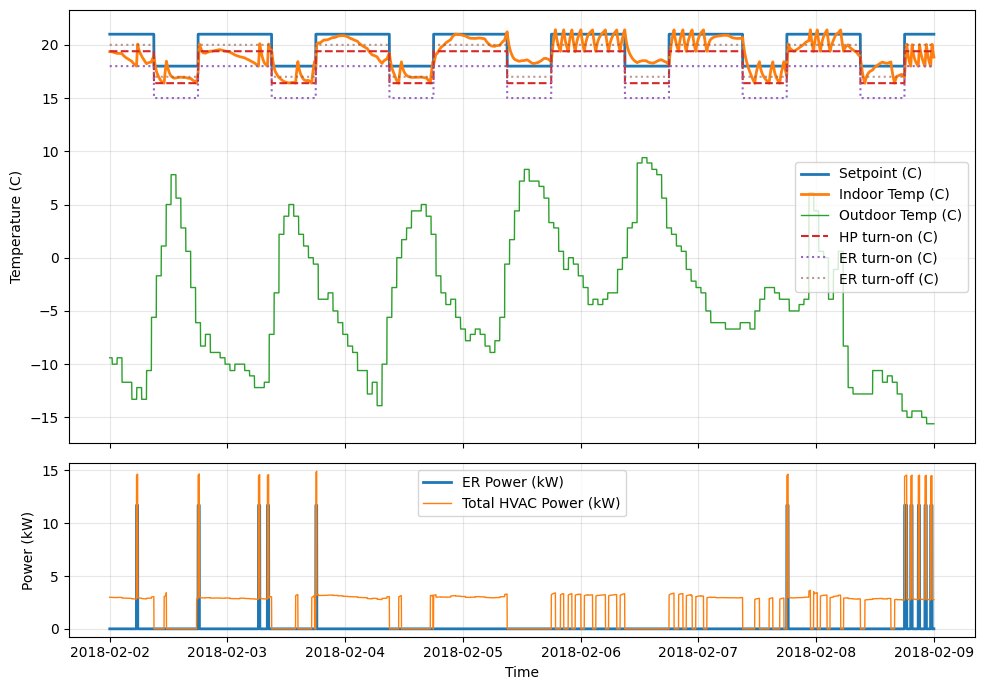

In [28]:
# --- Slice time window if requested ---
t_start = df_mpc.index[0]
t_end = df_mpc.index[-1]

# Column names from OCHRE Outputs.rst
T_set = df_mpc["HVAC Heating Setpoint (C)"]
T_in  = df_mpc["Temperature - Indoor (C)"]

# Optional series – only plot if they exist
T_out = df_mpc.get("Temperature - Outdoor (C)")
P_hp  = df_mpc.get("HVAC Heating Electric Power (kW)")        # total HP+ER
P_er  = df_mpc.get("HVAC Heating ER Power (kW)")              # ER only, if verbosity >= 7

# --- Reconstruct thermostat thresholds from HVAC.py ---

db   = heater.temp_deadband
off  = heater.deadband_offset
er_o = heater.er_setpoint_offset
hvac_mult = heater.hvac_mult   # +1 for heating

# HP thermostat (run_thermostat_control)
T_hp_on  = T_set - hvac_mult * db * (1 - off)
T_hp_off = T_set + hvac_mult * db * (off)

# ER thermostat (run_er_thermostat_control)
T_er_on  = T_set - er_o
T_er_off = T_er_on + db

# --- Plot ---

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [2.5, 1]}
)

# Temperatures & thresholds
ax1.plot(df_mpc.index, T_set,  label="Setpoint (C)",            linewidth=2)
ax1.plot(df_mpc.index, T_in,   label="Indoor Temp (C)",         linewidth=2)
if T_out is not None:
    ax1.plot(df_mpc.index, T_out, label="Outdoor Temp (C)",     linewidth=1)

ax1.plot(df_mpc.index, T_hp_on,  "--", label="HP turn-on (C)")
ax1.plot(df_mpc.index, T_er_on,  ":",  label="ER turn-on (C)")
ax1.plot(df_mpc.index, T_er_off, ":",  label="ER turn-off (C)", alpha=0.6)

ax1.set_ylabel("Temperature (C)")
ax1.legend(loc="best")
ax1.grid(True, alpha=0.3)

# Power – HP/ER
if P_er is not None:
    ax2.plot(df_mpc.index, P_er, label="ER Power (kW)", linewidth=2)
if P_hp is not None:
    ax2.plot(df_mpc.index, P_hp, label="Total HVAC Power (kW)", linewidth=1)

ax2.set_ylabel("Power (kW)")
ax2.set_xlabel(df_mpc.index.name or "Time")
ax2.legend(loc="best")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [21]:
# --- Slice time window if requested ---
days_in = 2
days_look = 1
#t_start = df_ctr.index[days_in*24*60]
#t_end = df_ctr.index[days_in*24*60 + days_look*24*60]
t_start = days_in*24*60
t_end = days_in*24*60 + days_look*24*60

# Column names from OCHRE Outputs.rst
T_set = df_ctr["HVAC Heating Setpoint (C)"]
T_in  = df_ctr["Temperature - Indoor (C)"]

# Optional series – only plot if they exist
T_out = df_ctr.get("Temperature - Outdoor (C)")
P_hp  = df_ctr.get("HVAC Heating Electric Power (kW)")        # total HP+ER
P_er  = df_ctr.get("HVAC Heating ER Power (kW)")              # ER only, if verbosity >= 7

T_min, T_max = comfort_schedule(df_ctr.index[days_in*24*60], 
                                n_horizon=days_look*24*60, time_step = 1)

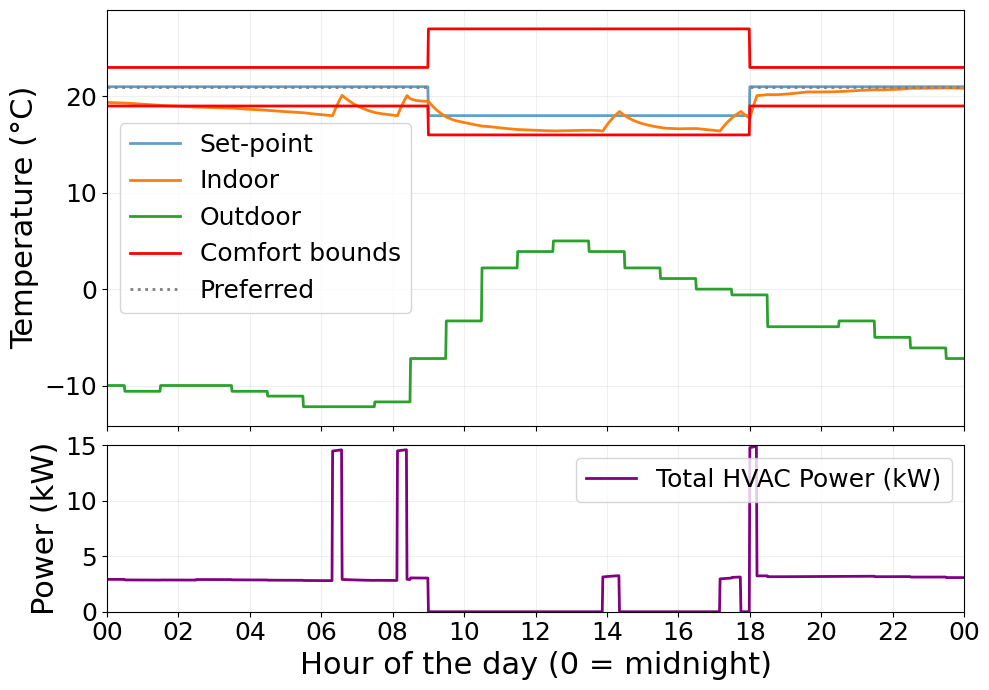

In [22]:
fs = 22

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [2.5, 1]}
)

# Temperatures & thresholds
ax1.plot(df_ctr.index[t_start:t_end], T_set[t_start:t_end], 
         label="Set-point", linewidth=2,alpha = 0.7)
ax1.plot(df_ctr.index[t_start:t_end], T_in[t_start:t_end], 
         label="Indoor", linewidth=2)
ax1.plot(df_ctr.index[t_start:t_end], T_out[t_start:t_end], 
         label="Outdoor", linewidth=2)
ax1.plot(df_ctr.index[t_start:t_end], T_min,
         linewidth=2, color='red', )
ax1.plot(df_ctr.index[t_start:t_end], T_max, label="Comfort bounds",
         linewidth=2, color='red')


#-- add preference temp --
idx = df_ctr.index[t_start:t_end]
hours = idx.hour

# True where you want to show T_pref (outside 9–16)
mask = (hours < 9) | (hours > 17)

# Find contiguous segments of True in mask and plot them
in_segment = False
start = 0
for i in range(len(idx)):
    if mask[i] and not in_segment:
        # start of a new "outside 9–16" segment
        start = i
        in_segment = True
    elif (not mask[i] and in_segment):
        # end of segment at i-1
        end = i
        ax1.plot(
            idx[start:end],
            [T_pref] * (end - start),
            linestyle=':',
            color='grey',
            linewidth=2,
        )
        in_segment = False

# If we ended while still in a segment, close it
if in_segment:
    end = len(idx)
    ax1.plot(
        idx[start:end],
        [T_pref] * (end - start),
        linestyle=':',
        color='grey',
        linewidth=2,
        label = 'Preferred'
    )

ax1.grid(True, alpha=0.2)   
ax1.legend(loc="best", fontsize = fs-4)
ax1.set_ylabel("Temperature (\u00b0C)", fontsize = fs)
ax1.tick_params(axis='y', which='major', labelsize = fs-4)
#ax1.set_xlabel("Hour of the day (0 = midnight)")

# Power – HP/ER
ax2.plot(df_ctr.index[t_start:t_end], P_hp[t_start:t_end], label=("Total HVAC "
                                                                 "Power (kW)"
                                                                  ""), 
         linewidth=2, color = 'purple')


ax2.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H'))

ax2.set_ylabel("Power (kW)", fontsize = fs)
ax2.set_xlabel("Hour of the day (0 = midnight)", fontsize = fs)
ax2.legend(loc="best", fontsize = fs-4)
ax2.grid(True, alpha=0.2)
ax2.tick_params(axis='x', which='major', labelsize = fs-4)
ax2.tick_params(axis='y', which='major', labelsize = fs-4)
ax2.set_ylim(0, 15)

# Force x-axis to run from midnight to midnight
day = idx[0].normalize()            # Midnight of that day
start_midnight = day                # 00:00
end_midnight   = day + pd.Timedelta(days=1)  # 24:00 next day

ax1.set_xlim(start_midnight, end_midnight)
ax2.set_xlim(start_midnight, end_midnight)


plt.tight_layout()
plt.savefig("base_example.png", format="png", dpi=600)
plt.show()